<a href="https://colab.research.google.com/github/themeynoush/AI-Material/blob/main/Orness_day1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏗️ Linear Regression — The Complete ML Lifecycle

**Requested by Orness. themeynoush@gmail.com: author email**

This notebook walks you through building a linear regression model end-to-end, covering every stage of the machine learning lifecycle.

---

## Table of Contents

1. [Key Terminology](#1-key-terminology)
2. [Data Ingestion](#2-data-ingestion)
3. [Exploratory Data Analysis (EDA)](#3-eda)
4. [Data Preparation & Cleaning](#4-data-preparation)
5. [Normalization — What, Why, When](#5-normalization)
6. [Train / Validation / Test Split](#6-splitting)
7. [Training the Model](#7-training)
8. [Batches & Epochs Explained](#8-batches-and-epochs)
9. [Evaluation: MSE vs MAE & Outlier Handling](#9-evaluation)
10. [Putting It All Together](#10-summary)

---
## 1. Key Terminology <a id='1-key-terminology'></a>

Before we write a single line of code, let's nail the vocabulary.

| Term | Meaning |
|---|---|
| **Feature (X)** | An input variable used to make predictions (e.g., square footage) |
| **Target / Label (y)** | The value we want to predict (e.g., house price) |
| **Sample / Instance** | One row of data |
| **Model** | A mathematical function that maps features → target |
| **Parameters (weights, bias)** | Values the model *learns* during training |
| **Hyperparameters** | Values *you* set before training (learning rate, epochs, batch size) |
| **Loss / Cost Function** | Measures how wrong the model's predictions are |
| **Optimizer** | Algorithm that updates parameters to reduce the loss (e.g., SGD, Adam) |
| **Learning Rate (α)** | Step size for each parameter update — too big = overshoot, too small = slow |
| **Epoch** | One complete pass through the entire training dataset |
| **Batch** | A subset of training data used in one parameter update |
| **Batch Size** | Number of samples per batch |
| **Iteration / Step** | One parameter update = processing one batch |
| **Overfitting** | Model memorizes training data, fails on new data |
| **Underfitting** | Model is too simple to capture the pattern |
| **Generalization** | Model performs well on unseen data |
| **Normalization / Scaling** | Transforming features to a common range |
| **Training Set** | Data used to learn parameters (~60-80%) |
| **Validation Set** | Data used to tune hyperparameters (~10-20%) |
| **Test Set** | Data used for final, unbiased evaluation (~10-20%) |

### Epoch, Batch, Iteration — The Relationship

```
If you have 1000 samples and batch_size = 100:
  → 1 epoch = 1000 / 100 = 10 iterations (steps)
  → 5 epochs = 50 iterations total
```

**Why batches?** Processing all data at once (batch gradient descent) is memory-expensive and slow for large datasets. Mini-batches give faster updates that often converge better.

| Strategy | Batch Size | Pros | Cons |
|---|---|---|---|
| Batch GD | All samples | Stable gradients | Slow, memory-heavy |
| Mini-Batch GD | 16–512 | Good balance | Need to tune batch size |
| Stochastic GD (SGD) | 1 | Fast updates | Very noisy gradients |

---
## 2. Data Ingestion <a id='2-data-ingestion'></a>

We'll use the **California Housing** dataset — a real dataset predicting median house values from census features.

In [1]:
# Install dependencies if needed
# !pip install scikit-learn pandas numpy matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

# Load the dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame  # Full DataFrame including target

print(f"Dataset shape: {df.shape}")
print(f"Features: {list(housing.feature_names)}")
print(f"Target: MedHouseVal (median house value in $100k)")
df.head()

Dataset shape: (20640, 9)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target: MedHouseVal (median house value in $100k)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


---
## 3. Exploratory Data Analysis (EDA) <a id='3-eda'></a>

Before doing anything, **look at your data**. Skipping EDA is how you build garbage models.

In [2]:
# Basic statistics
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [3]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing values per column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Total missing: 0


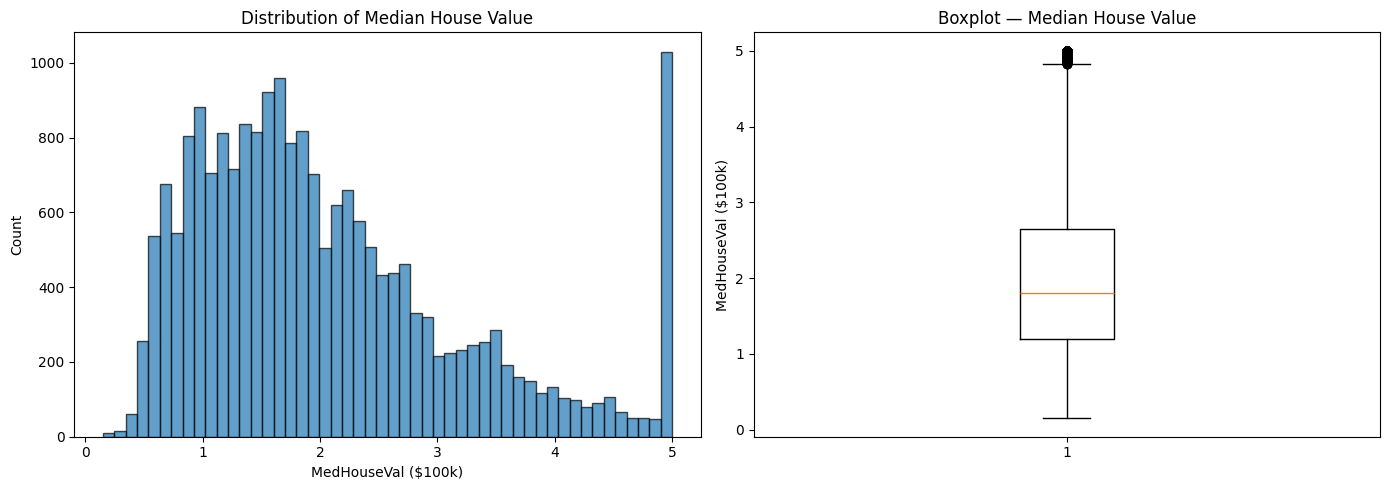

⚠️ Notice the spike at 5.0 — these are capped values (houses worth $500k+).
   This is a form of data quality issue we need to be aware of.


In [4]:
# Distribution of the target variable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['MedHouseVal'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Median House Value')
axes[0].set_xlabel('MedHouseVal ($100k)')
axes[0].set_ylabel('Count')

# Boxplot to spot outliers
axes[1].boxplot(df['MedHouseVal'], vert=True)
axes[1].set_title('Boxplot — Median House Value')
axes[1].set_ylabel('MedHouseVal ($100k)')

plt.tight_layout()
plt.show()

print("⚠️ Notice the spike at 5.0 — these are capped values (houses worth $500k+).")
print("   This is a form of data quality issue we need to be aware of.")

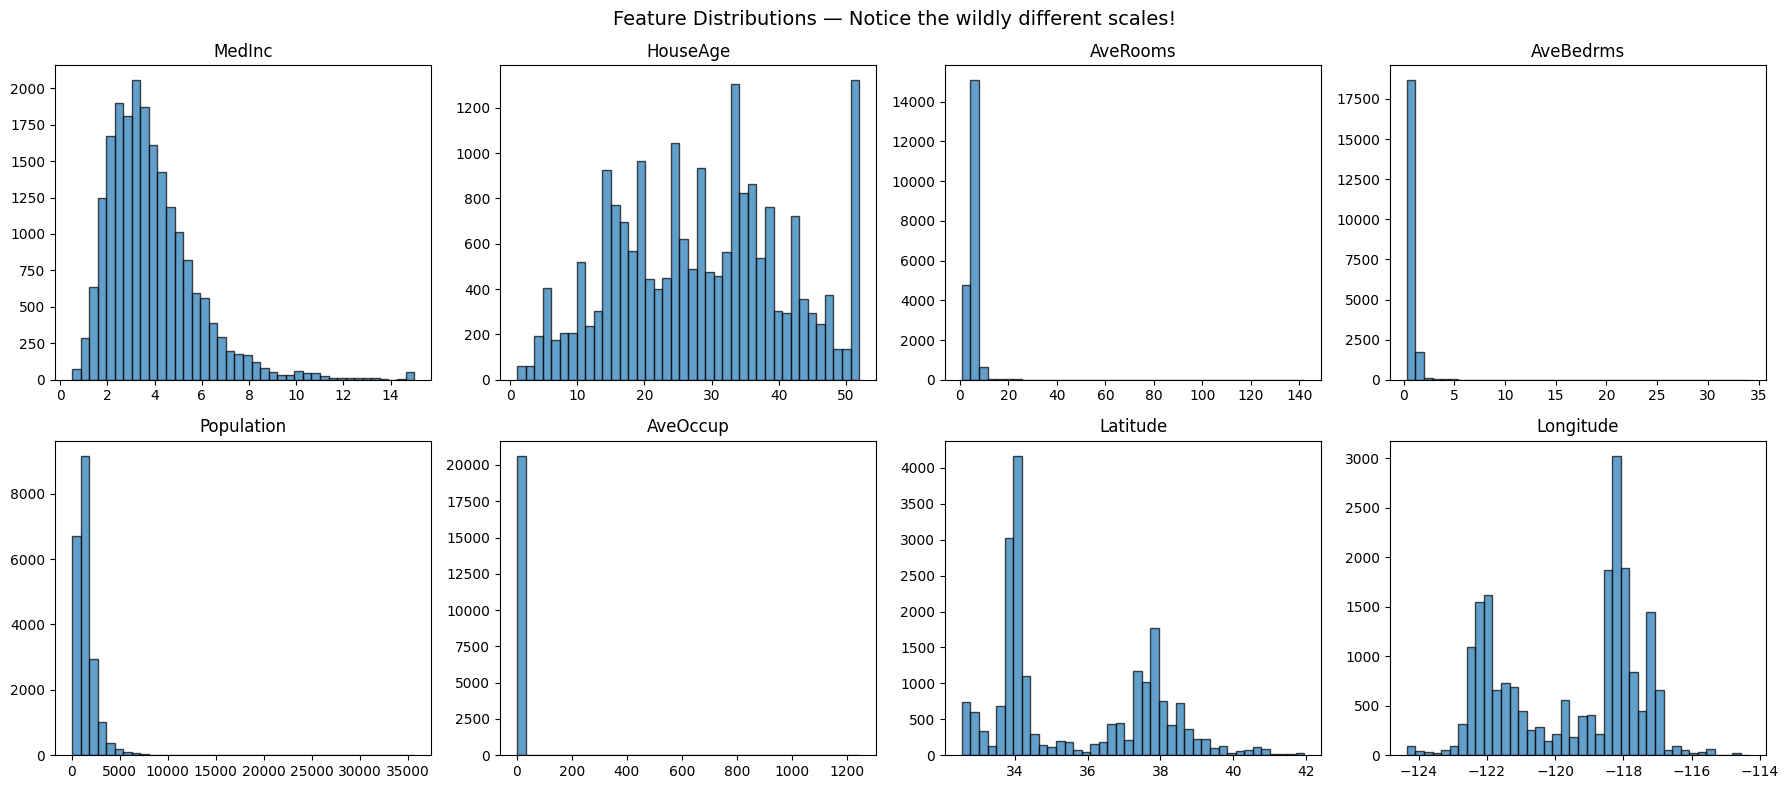

In [ ]:
# Feature distributions — notice the different scales!
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, col in enumerate(housing.feature_names):
    ax = axes[i // 4, i % 4]
    ax.hist(df[col], bins=40, edgecolor='black', alpha=0.7)
    ax.set_title(col)
plt.suptitle('Feature Distributions — Notice the wildly different scales!', fontsize=14)
plt.tight_layout()
plt.show()

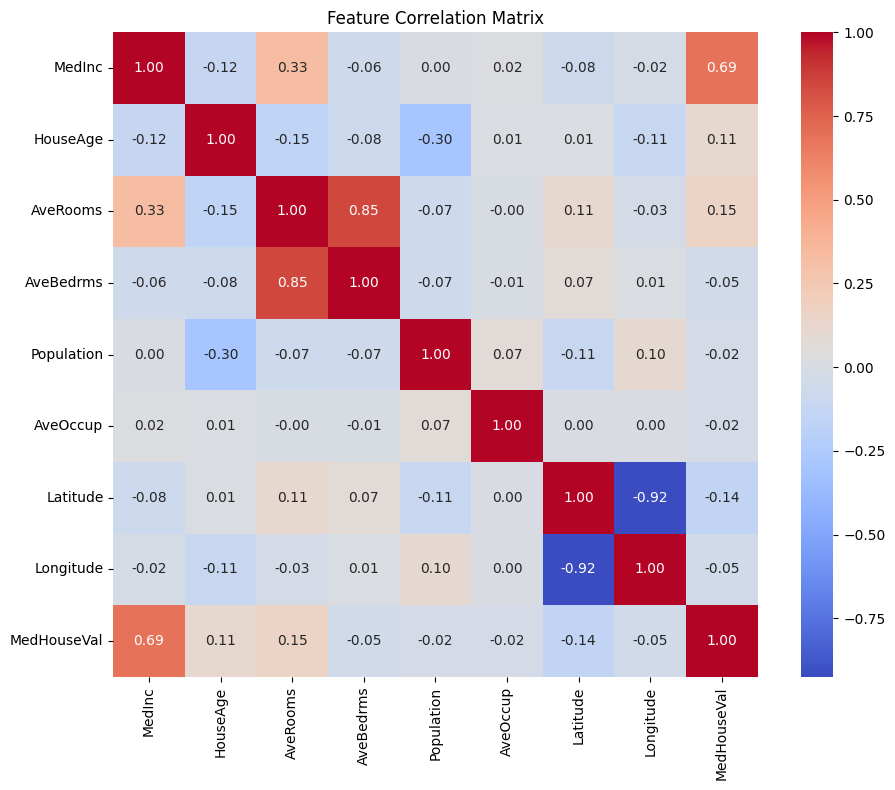

Key insight: MedInc (median income) has the strongest correlation with house value.
AveRooms and AveBedrms are correlated with each other (multicollinearity).


In [5]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

print("Key insight: MedInc (median income) has the strongest correlation with house value.")
print("AveRooms and AveBedrms are correlated with each other (multicollinearity).")

---
## 4. Data Preparation & Cleaning <a id='4-data-preparation'></a>

Real-world data is messy. Here's what you typically handle:

- **Missing values** → impute or drop
- **Outliers** → cap, remove, or use robust methods
- **Feature engineering** → create new informative features
- **Encoding** → convert categorical variables to numbers (not needed here — all numeric)

In [6]:
# Step 1: Handle the capped target values
# Values at exactly 5.0 are capped — let's remove them for cleaner regression
print(f"Rows before cleaning: {len(df)}")
df_clean = df[df['MedHouseVal'] < 5.0].copy()
print(f"Rows after removing capped values: {len(df_clean)}")
print(f"Removed: {len(df) - len(df_clean)} rows ({(len(df) - len(df_clean)) / len(df) * 100:.1f}%)")

Rows before cleaning: 20640
Rows after removing capped values: 19648
Removed: 992 rows (4.8%)


In [ ]:
# Step 2: Handle outliers in features using IQR capping
def cap_outliers(series, factor=3.0):
    """Cap values beyond factor * IQR from Q1/Q3."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    return series.clip(lower, upper)

# Cap extreme outliers in Population and AveOccup
for col in ['Population', 'AveOccup', 'AveRooms', 'AveBedrms']:
    before = df_clean[col].describe()
    df_clean[col] = cap_outliers(df_clean[col])
    print(f"{col}: max {before['max']:.1f} → {df_clean[col].max():.1f}")

Population: max 35682.0 → 4597.0
AveOccup: max 1243.3 → 5.9
AveRooms: max 132.5 → 10.6
AveBedrms: max 34.1 → 1.4


In [7]:
# Step 3: Separate features and target
X = df_clean.drop('MedHouseVal', axis=1)
y = df_clean['MedHouseVal']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature ranges (before normalization):")
print(X.describe().loc[['min', 'max']].T)

Features shape: (19648, 8)
Target shape: (19648,)

Feature ranges (before normalization):
                   min           max
MedInc        0.499900     15.000100
HouseAge      1.000000     52.000000
AveRooms      0.846154    132.533333
AveBedrms     0.333333     34.066667
Population    3.000000  35682.000000
AveOccup      0.692308   1243.333333
Latitude     32.540000     41.950000
Longitude  -124.350000   -114.310000


---
## 5. Normalization — What, Why, When <a id='5-normalization'></a>

### What is Normalization/Scaling?

Transforming features so they're on a comparable scale.

### Common Methods

| Method | Formula | Range | When to Use |
|---|---|---|---|
| **Min-Max Scaling** | (x - min) / (max - min) | [0, 1] | When you need bounded values; no extreme outliers |
| **Standard Scaling (Z-score)** | (x - μ) / σ | ~[-3, 3] | Most common; works with outliers; assumes ~normal distribution |
| **Robust Scaling** | (x - median) / IQR | varies | When you have significant outliers |

### When to Normalize ✅

- Features have **different scales** (e.g., income: 0-15, population: 0-35000)
- Using **gradient-based optimization** (gradient descent converges faster with scaled features)
- Using **distance-based algorithms** (KNN, SVM, K-means)
- Using **regularization** (L1/L2 penalties are scale-sensitive)

### When NOT to Normalize ❌

- **Tree-based models** (Decision Trees, Random Forest, XGBoost) — they split on thresholds, scale doesn't matter
- Features are **already on the same scale**
- You need **interpretable coefficients** in the original units

### ⚠️ Critical Rule: Fit on Training Data ONLY

```python
# ✅ CORRECT
scaler.fit(X_train)           # Learn μ, σ from training set
X_train = scaler.transform(X_train)
X_val   = scaler.transform(X_val)   # Use SAME μ, σ
X_test  = scaler.transform(X_test)  # Use SAME μ, σ

# ❌ WRONG — data leakage!
scaler.fit(X)  # Fitting on ALL data leaks test info into training
```

Why? Because in production, you won't have future data. The scaler must only know about training data.

---
## 6. Train / Validation / Test Split <a id='6-splitting'></a>

### Why Three Sets?

| Set | Purpose | Used For |
|---|---|---|
| **Training** | Learn model parameters | `model.fit()` |
| **Validation** | Tune hyperparameters, detect overfitting | Comparing models, early stopping |
| **Test** | Final unbiased evaluation | Report final metrics — touch this ONCE |

**Common mistake:** Using only train/test, then tuning on test → your test score is biased.

**The rule:** Test set = sealed envelope. Open it once at the very end.

In [16]:
from sklearn.model_selection import train_test_split

# First split: 80% train+val, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Second split: of the 80%, take 75% train, 25% val → overall 60/20/20
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)

print(f"Training set:   {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"Test set:       {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)")

Training set:   11788 samples (60%)
Validation set: 3930 samples (20%)
Test set:       3930 samples (20%)


In [17]:
# Now apply normalization — fit ONLY on training data!
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit + transform
X_val_scaled = scaler.transform(X_val)           # transform only
X_test_scaled = scaler.transform(X_test)         # transform only

# Convert back to DataFrames for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("After Standard Scaling (training set):")
print(X_train_scaled.describe().loc[['mean', 'std', 'min', 'max']].T)
print("\n✅ Mean ≈ 0, Std ≈ 1 — exactly what we want.")

After Standard Scaling (training set):
                    mean       std       min        max
MedInc      1.181425e-16  1.000042 -2.011756   7.175790
HouseAge    1.308006e-16  1.000042 -2.185607   1.863966
AveRooms   -2.531625e-17  1.000042 -1.799853  50.489203
AveBedrms  -1.211563e-16  1.000042 -1.482690  63.848256
Population  8.197643e-17  1.000042 -1.253130  29.895429
AveOccup   -7.534598e-18  1.000042 -0.307398  78.710758
Latitude   -1.103065e-15  1.000042 -1.457542   2.911811
Longitude   1.958995e-15  1.000042 -2.369660   2.625132

✅ Mean ≈ 0, Std ≈ 1 — exactly what we want.


---
## 7. Training the Model <a id='7-training'></a>

### What is Linear Regression?

It finds the best line (hyperplane in multiple dimensions) through your data:

$$\hat{y} = w_1 x_1 + w_2 x_2 + \ldots + w_n x_n + b$$

Where:
- $w_i$ = weights (learned)
- $b$ = bias/intercept (learned)
- $\hat{y}$ = prediction

"Best" means minimizing the loss function (typically MSE).

### Two approaches:
1. **Closed-form (Normal Equation)** — exact solution, what sklearn uses
2. **Gradient Descent** — iterative, needed for large datasets and neural nets

We'll do both!

In [18]:
# === Approach 1: Scikit-learn (Closed-form solution) ===
from sklearn.linear_model import LinearRegression

model_sklearn = LinearRegression()
model_sklearn.fit(X_train_scaled, y_train)

print("Learned coefficients (weights):")
for name, coef in zip(X.columns, model_sklearn.coef_):
    print(f"  {name:15s}: {coef:+.4f}")
print(f"  {'Bias (intercept)':15s}: {model_sklearn.intercept_:+.4f}")

print("\nInterpretation: MedInc has the largest positive weight")
print("→ Higher income areas have higher house values. Makes sense!")

Learned coefficients (weights):
  MedInc         : +0.6706
  HouseAge       : +0.0983
  AveRooms       : -0.2467
  AveBedrms      : +0.2785
  Population     : +0.0080
  AveOccup       : -0.0221
  Latitude       : -0.8178
  Longitude      : -0.7976
  Bias (intercept): +1.9192

Interpretation: MedInc has the largest positive weight
→ Higher income areas have higher house values. Makes sense!


In [24]:
# === Approach 2: Gradient Descent from Scratch ===
# This is what actually happens under the hood in deep learning

class LinearRegressionGD:
    """Linear Regression using Mini-Batch Gradient Descent."""

    def __init__(self, learning_rate=0.01):
        self.lr = learning_rate
        self.weights = None
        self.bias = None
        self.history = {'train_loss': [], 'val_loss': []}

    def predict(self, X):
        return X @ self.weights + self.bias

    def _mse_loss(self, y_true, y_pred):
        return np.mean((y_true - y_pred) ** 2)

    def fit(self, X_train, y_train, X_val, y_val,
            epochs=100, batch_size=64, verbose=True):
        """
        Train with mini-batch gradient descent.

        epochs: how many full passes through the training data
        batch_size: samples per gradient update
        """
        X_train = np.array(X_train)
        y_train = np.array(y_train)
        X_val = np.array(X_val)
        y_val = np.array(y_val)

        n_samples, n_features = X_train.shape
        n_batches = int(np.ceil(n_samples / batch_size))

        # Initialize parameters
        self.weights = np.zeros(n_features)
        self.bias = 0.0

        for epoch in range(epochs):
            # Shuffle training data each epoch
            indices = np.random.permutation(n_samples)
            X_shuffled = X_train[indices]
            y_shuffled = y_train[indices]

            # Mini-batch loop
            for batch_idx in range(n_batches):
                start = batch_idx * batch_size
                end = min(start + batch_size, n_samples)

                X_batch = X_shuffled[start:end]
                y_batch = y_shuffled[start:end]
                batch_n = len(y_batch)

                # Forward pass
                y_pred = X_batch @ self.weights + self.bias

                # Compute gradients
                error = y_pred - y_batch
                dw = (2 / batch_n) * (X_batch.T @ error)
                db = (2 / batch_n) * np.sum(error)

                # Update parameters
                self.weights -= self.lr * dw
                self.bias -= self.lr * db

            # Record epoch-level losses
            train_loss = self._mse_loss(y_train, self.predict(X_train))
            val_loss = self._mse_loss(y_val, self.predict(X_val))
            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)

            if verbose and (epoch + 1) % 20 == 0:
                print(f"Epoch {epoch+1:3d}/{epochs} | "
                      f"Train MSE: {train_loss:.4f} | Val MSE: {val_loss:.4f} | "
                      f"Batches/epoch: {n_batches}")

        return self

# Train!
model_gd = LinearRegressionGD(learning_rate=0.004)
model_gd.fit(
    X_train_scaled, y_train,
    X_val_scaled, y_val,
    epochs=100,
    batch_size=64
)

Epoch  20/100 | Train MSE: 0.4080 | Val MSE: 0.3919 | Batches/epoch: 185
Epoch  40/100 | Train MSE: 0.4040 | Val MSE: 0.3855 | Batches/epoch: 185
Epoch  60/100 | Train MSE: 0.4041 | Val MSE: 0.3873 | Batches/epoch: 185
Epoch  80/100 | Train MSE: 0.4053 | Val MSE: 0.3914 | Batches/epoch: 185
Epoch 100/100 | Train MSE: 0.4031 | Val MSE: 0.3860 | Batches/epoch: 185


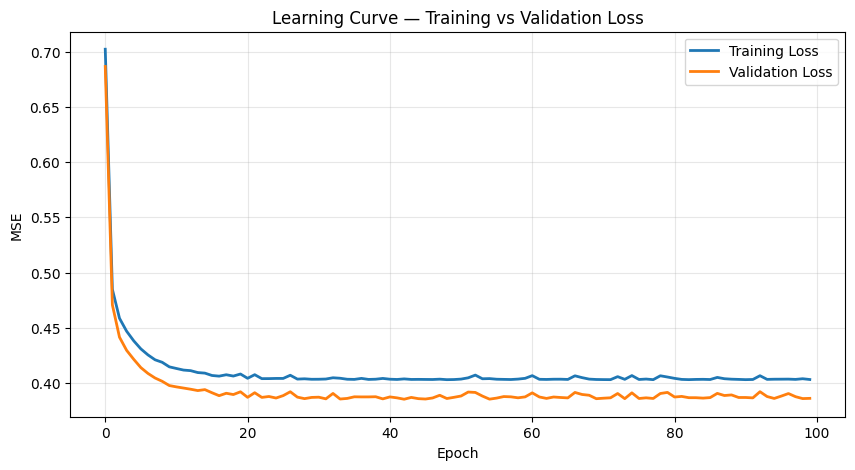

📊 What to look for:
  • Both curves decreasing → model is learning
  • Val loss stops decreasing while train keeps going → overfitting starts
  • Big gap between curves → overfitting
  • Both curves plateau high → underfitting


In [25]:
# Plot training curves — this is how you monitor training
plt.figure(figsize=(10, 5))
plt.plot(model_gd.history['train_loss'], label='Training Loss', linewidth=2)
plt.plot(model_gd.history['val_loss'], label='Validation Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Learning Curve — Training vs Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("📊 What to look for:")
print("  • Both curves decreasing → model is learning")
print("  • Val loss stops decreasing while train keeps going → overfitting starts")
print("  • Big gap between curves → overfitting")
print("  • Both curves plateau high → underfitting")

---
## 8. Batches & Epochs — Deep Dive <a id='8-batches-and-epochs'></a>

Let's **visualize** how batch size affects training.

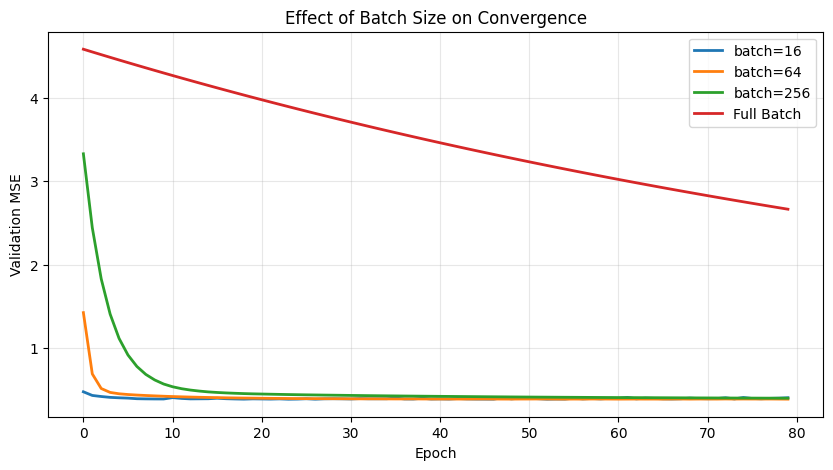

Observations:
  • Smaller batches → noisier but often faster initial convergence
  • Larger batches → smoother but may need more epochs
  • Full batch → smoothest but slowest per epoch on big data
  • Sweet spot is usually 32-256 for most problems


In [32]:
# Compare different batch sizes
batch_sizes = [16, 64, 256, len(X_train)]  # SGD-ish, mini-batch, larger, full-batch
results = {}

for bs in batch_sizes:
    label = f"batch={bs}" if bs < len(X_train) else "Full Batch"
    m = LinearRegressionGD(learning_rate=0.002)
    m.fit(X_train_scaled, y_train, X_val_scaled, y_val,
          epochs=80, batch_size=bs, verbose=False)
    results[label] = m.history['val_loss']

plt.figure(figsize=(10, 5))
for label, losses in results.items():
    plt.plot(losses, label=label, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Validation MSE')
plt.title('Effect of Batch Size on Convergence')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Observations:")
print("  • Smaller batches → noisier but often faster initial convergence")
print("  • Larger batches → smoother but may need more epochs")
print("  • Full batch → smoothest but slowest per epoch on big data")
print("  • Sweet spot is usually 32-256 for most problems")

---
## 9. Evaluation: MSE vs MAE & Outlier Handling <a id='9-evaluation'></a>

### Loss Functions Compared

| Metric | Formula | Outlier Sensitivity | When to Use |
|---|---|---|---|
| **MSE** (Mean Squared Error) | $\frac{1}{n}\sum(y - \hat{y})^2$ | **High** — squares amplify large errors | When large errors are costly (e.g., financial predictions) |
| **RMSE** (Root MSE) | $\sqrt{MSE}$ | **High** | Same as MSE but in original units |
| **MAE** (Mean Absolute Error) | $\frac{1}{n}\sum|y - \hat{y}|$ | **Low** — treats all errors equally | When outliers exist and shouldn't dominate |
| **R² Score** | $1 - \frac{SS_{res}}{SS_{tot}}$ | Moderate | Overall model quality (1.0 = perfect) |

### Key Insight: MSE vs MAE on Outliers

If your data has outliers:
- **MSE penalizes outliers heavily** → model bends toward them
- **MAE is robust** → model ignores outlier pull

Let's prove this!

In [33]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Predictions on validation set
y_val_pred_sklearn = model_sklearn.predict(X_val_scaled)
y_val_pred_gd = model_gd.predict(np.array(X_val_scaled))

print("=" * 60)
print("VALIDATION SET RESULTS")
print("=" * 60)

for name, preds in [('Sklearn (closed-form)', y_val_pred_sklearn),
                     ('Gradient Descent', y_val_pred_gd)]:
    mse = mean_squared_error(y_val, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_val, preds)
    r2 = r2_score(y_val, preds)
    print(f"\n{name}:")
    print(f"  MSE:  {mse:.4f}")
    print(f"  RMSE: {rmse:.4f} ($100k)")
    print(f"  MAE:  {mae:.4f} ($100k)")
    print(f"  R²:   {r2:.4f}")

VALIDATION SET RESULTS

Sklearn (closed-form):
  MSE:  0.3860
  RMSE: 0.6213 ($100k)
  MAE:  0.4678 ($100k)
  R²:   0.5777

Gradient Descent:
  MSE:  0.3860
  RMSE: 0.6213 ($100k)
  MAE:  0.4680 ($100k)
  R²:   0.5777


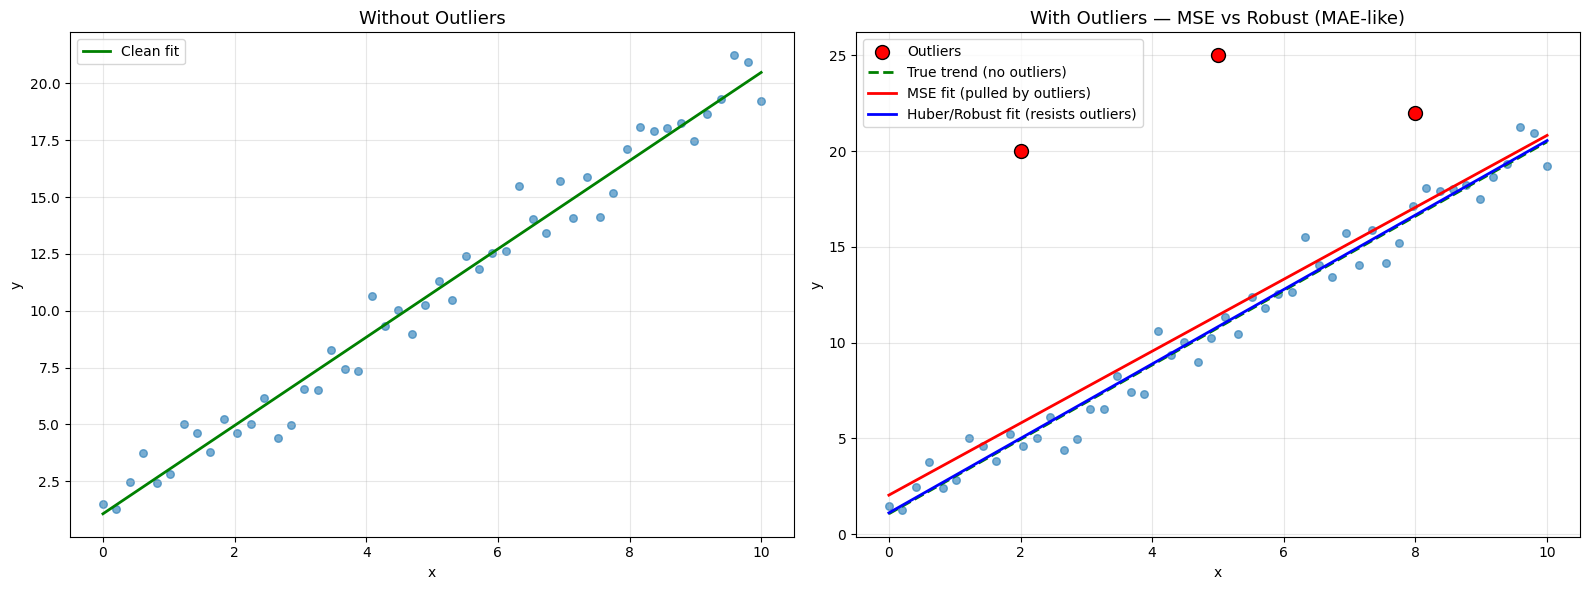

🔑 Key takeaway:
  • MSE-based regression (red) gets PULLED toward outliers
  • Robust/MAE-based regression (blue) stays close to the true trend
  • If your data has outliers you can't remove, prefer MAE or Huber loss


In [34]:
# === Demonstrate MSE vs MAE sensitivity to outliers ===

# Create a simple 1D example to make the point crystal clear
np.random.seed(42)
x_demo = np.linspace(0, 10, 50).reshape(-1, 1)
y_demo = 2 * x_demo.ravel() + 1 + np.random.normal(0, 1, 50)

# Add outliers
x_outliers = np.array([[2], [5], [8]])
y_outliers = np.array([20, 25, 22])  # Way above the trend

x_with_outliers = np.vstack([x_demo, x_outliers])
y_with_outliers = np.hstack([y_demo, y_outliers])

# Fit models: one on clean data, one on data with outliers
from sklearn.linear_model import LinearRegression, HuberRegressor

model_clean = LinearRegression().fit(x_demo, y_demo)
model_outlier_mse = LinearRegression().fit(x_with_outliers, y_with_outliers)  # MSE-based
model_outlier_robust = HuberRegressor().fit(x_with_outliers, y_with_outliers)  # Robust (MAE-like)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x_line = np.linspace(0, 10, 100).reshape(-1, 1)

for ax, title, x_data, y_data in [
    (axes[0], 'Without Outliers', x_demo, y_demo),
    (axes[1], 'With Outliers — MSE vs Robust (MAE-like)', x_with_outliers, y_with_outliers)
]:
    ax.scatter(x_data, y_data, alpha=0.6, s=30)
    if ax == axes[1]:
        ax.scatter(x_outliers, y_outliers, color='red', s=100, zorder=5,
                   label='Outliers', edgecolors='black')
        ax.plot(x_line, model_clean.predict(x_line), 'g--',
                label='True trend (no outliers)', linewidth=2)
        ax.plot(x_line, model_outlier_mse.predict(x_line), 'r-',
                label='MSE fit (pulled by outliers)', linewidth=2)
        ax.plot(x_line, model_outlier_robust.predict(x_line), 'b-',
                label='Huber/Robust fit (resists outliers)', linewidth=2)
        ax.legend(fontsize=10)
    else:
        ax.plot(x_line, model_clean.predict(x_line), 'g-',
                label='Clean fit', linewidth=2)
        ax.legend()
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("🔑 Key takeaway:")
print("  • MSE-based regression (red) gets PULLED toward outliers")
print("  • Robust/MAE-based regression (blue) stays close to the true trend")
print("  • If your data has outliers you can't remove, prefer MAE or Huber loss")

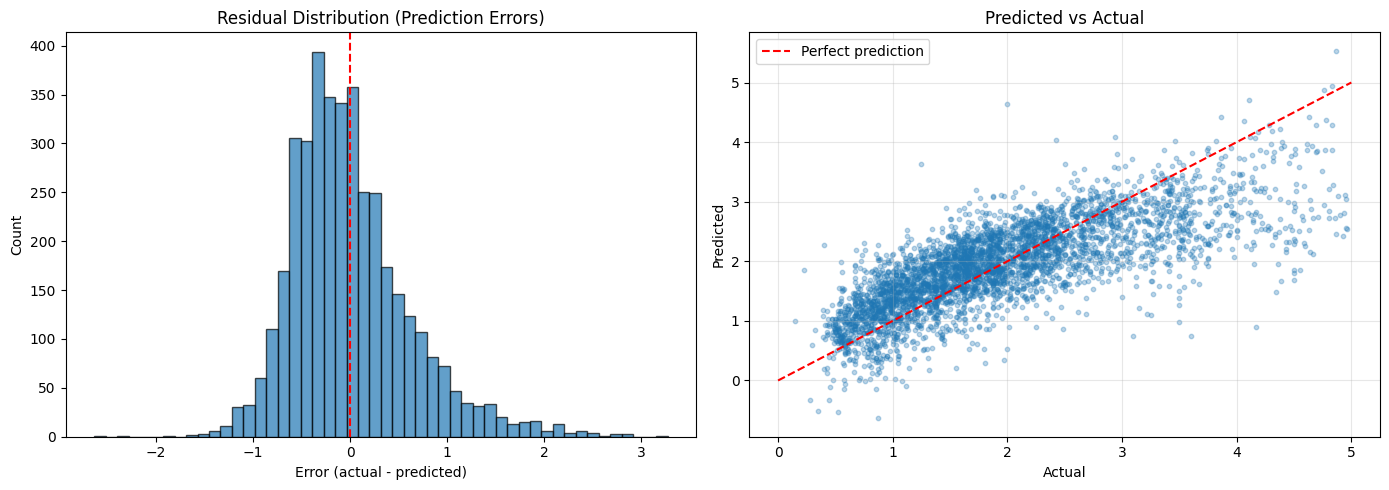


Top 5 largest absolute errors:
  Error: 3.274 → Squared: 10.718 → Absolute: 3.274
  Error: 2.864 → Squared: 8.200 → Absolute: 2.864
  Error: 2.859 → Squared: 8.171 → Absolute: 2.859
  Error: 2.811 → Squared: 7.899 → Absolute: 2.811
  Error: 2.720 → Squared: 7.396 → Absolute: 2.720

  Notice: squaring a 2.5 error gives 6.25 — MSE amplifies big mistakes!


In [35]:
# Quantify the difference on our housing data
errors = y_val.values - y_val_pred_sklearn

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual distribution
axes[0].hist(errors, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Residual Distribution (Prediction Errors)')
axes[0].set_xlabel('Error (actual - predicted)')
axes[0].set_ylabel('Count')

# Predicted vs Actual
axes[1].scatter(y_val, y_val_pred_sklearn, alpha=0.3, s=10)
axes[1].plot([0, 5], [0, 5], 'r--', label='Perfect prediction')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
axes[1].set_title('Predicted vs Actual')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Show how individual large errors affect MSE vs MAE differently
sorted_abs_errors = np.sort(np.abs(errors))[::-1]
print("\nTop 5 largest absolute errors:")
for i in range(5):
    print(f"  Error: {sorted_abs_errors[i]:.3f} → "
          f"Squared: {sorted_abs_errors[i]**2:.3f} → "
          f"Absolute: {sorted_abs_errors[i]:.3f}")
print(f"\n  Notice: squaring a 2.5 error gives 6.25 — MSE amplifies big mistakes!")

---
## 10. Putting It All Together — Final Test Evaluation <a id='10-summary'></a>

Now — and ONLY now — we touch the test set.

In [36]:
# Final evaluation on the TEST set (first and only time!)
y_test_pred = model_sklearn.predict(X_test_scaled)

test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("=" * 60)
print("🏆 FINAL TEST SET RESULTS")
print("=" * 60)
print(f"  MSE:  {test_mse:.4f}")
print(f"  RMSE: {test_rmse:.4f} (${test_rmse * 100:.0f}k average error)")
print(f"  MAE:  {test_mae:.4f} (${test_mae * 100:.0f}k average error)")
print(f"  R²:   {test_r2:.4f} ({test_r2*100:.1f}% variance explained)")
print("\n📝 Interpretation:")
print(f"  The model explains ~{test_r2*100:.0f}% of house price variance.")
print(f"  On average, predictions are off by ~${test_mae * 100:.0f}k.")
print(f"  Not bad for a linear model! Non-linear models can do better.")

🏆 FINAL TEST SET RESULTS
  MSE:  0.4137
  RMSE: 0.6432 ($64k average error)
  MAE:  0.4830 ($48k average error)
  R²:   0.5685 (56.9% variance explained)

📝 Interpretation:
  The model explains ~57% of house price variance.
  On average, predictions are off by ~$48k.
  Not bad for a linear model! Non-linear models can do better.


---
## 📋 ML Lifecycle Summary

```
1. INGEST DATA          → Load raw data, understand what you have
2. EXPLORE (EDA)        → Distributions, correlations, anomalies
3. CLEAN & PREPARE      → Handle missing values, outliers, encoding
4. SPLIT                → Train / Validation / Test (don't leak!)
5. NORMALIZE            → Scale features (fit on train only!)
6. TRAIN                → Learn parameters (weights + bias)
7. VALIDATE             → Tune hyperparameters, check for overfitting
8. EVALUATE             → Final test metrics (once!)
9. DEPLOY (not covered) → Serve model in production
10. MONITOR (not covered)→ Track performance drift over time
```

### Key Takeaways

1. **Always split before scaling** — prevent data leakage
2. **Use validation set for tuning** — test set is sacred
3. **MSE punishes outliers hard** — use MAE or Huber when outliers exist
4. **Batch size is a tradeoff** — smaller = noisier but often faster learning
5. **More epochs ≠ better** — watch validation loss for overfitting
6. **Linear regression is a baseline** — always start here, then go complex
